# Process 2025 ANADIA

Just matching strings to assign PCODEs

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [7]:
import unicodedata
import re

import ocha_stratus as stratus
import pandas as pd

from src.datasources import codab
from src.constants import *

In [3]:
adm3 = codab.load_codab_from_blob(admin_level=3, aoi_only=False)

<Axes: >

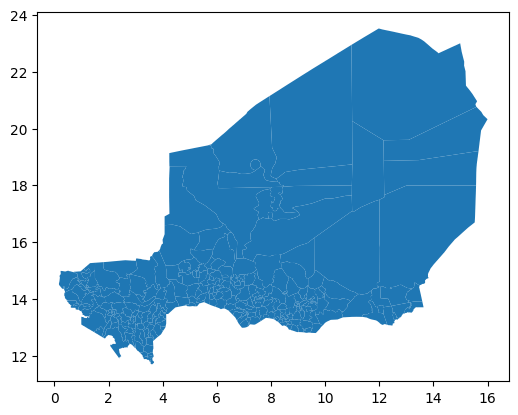

In [4]:
adm3.plot()

In [8]:
blob_name = f"{PROJECT_PREFIX}/raw/anadia/traité_1998-2024_FréqMoyenne.xlsx"
df_anadia = pd.read_excel(stratus.load_blob_data(blob_name))

/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_59743/612247269.py:2: FutureWarning: Passing bytes to 'read_excel' is deprecated and will be removed in a future version. To read from a byte string, wrap it in a `BytesIO` object.
  df_anadia = pd.read_excel(stratus.load_blob_data(blob_name))


In [9]:
def normalize_string(s):
    # Lowercase
    s = s.lower()
    # Remove accents
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    # Remove all non-alphanumeric characters
    s = re.sub(r"[^a-z0-9]", "", s)
    return s

In [59]:
df_anadia["Communes_norm"] = df_anadia["Communes"].apply(normalize_string)
adm3["adm3_match"] = adm3["ADM3_FR"].apply(normalize_string)

In [60]:
adm3[adm3.duplicated(subset="Communes_norm", keep=False)]

,ADM3_FR,ADM3_PCODE,ADM2_FR,ADM2_PCODE,ADM1_FR,ADM1_PCODE,ADM0_FR,ADM0_PCODE,DATE,VALIDON,VALIDTO,geometry,Communes_norm,adm3_match
69,Tibiri,NE003008004,Tibiri,NE003008,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,NaT,"POLYGON ((4.12911 13.23579, 4.12907 13.20991, ...",tibiri,tibiri
86,Gangara,NE004004001,Gazaoua,NE004004,Maradi,NE004,Niger (the),NE,2023-06-21,2023-07-25,NaT,"POLYGON ((7.91071 13.3278, 7.90413 13.3281, 7....",gangara,gangara
92,Tibiri,NE004005005,Guidan Roumdji,NE004005,Maradi,NE004,Niger (the),NE,2023-06-21,2023-07-25,NaT,"POLYGON ((6.7421 13.24658, 6.73691 13.25598, 6...",tibiri,tibiri
251,Gangara,NE007009002,Tanout,NE007009,Zinder,NE007,Niger (the),NE,2023-06-21,2023-07-25,NaT,"POLYGON ((8.50409 14.92908, 8.57068 14.84351, ...",gangara,gangara


In [79]:
def int_to_roman(num):
    val = [1000, 900, 500, 400, 100, 90, 50, 40, 10, 9, 5, 4, 1]
    syms = [
        "M",
        "CM",
        "D",
        "CD",
        "C",
        "XC",
        "L",
        "XL",
        "X",
        "IX",
        "V",
        "IV",
        "I",
    ]
    roman = ""
    for i in range(len(val)):
        count = num // val[i]
        roman += syms[i] * count
        num -= val[i] * count
    return roman


def int_to_roman_name_dict(name, max_int):
    return {
        f"{name}{x}": f"{name}{int_to_roman(x).lower()}"
        for x in range(1, max_int + 1)
    }

In [104]:
correct_names = {
    "falenco": "falenko",
}
correct_names.update(int_to_roman_name_dict("niamey", 5))
correct_names.update(int_to_roman_name_dict("maradi", 3))
correct_names.update(int_to_roman_name_dict("tahoua", 2))
correct_names.update(int_to_roman_name_dict("zinder", 5))
correct_names.update(int_to_roman_name_dict("tombokoirey", 2))
correct_names.update(int_to_roman_name_dict("roumbou", 1))
df_anadia["adm3_match"] = df_anadia["Communes_norm"].replace(correct_names)

In [114]:
specific_pcodes = {
    "tibirimaradi": "NE004005005",
    "tibiridoutchi": "NE003008004",
    "gangaratanout": "NE007009002",
    "gangaraaguie": "NE004004001",
}

In [147]:
df_anadia_merge = df_anadia.merge(
    adm3[["adm3_match", "ADM3_PCODE"]], how="outer"
)
df_anadia_merge["ADM3_PCODE"] = df_anadia_merge["ADM3_PCODE"].fillna(
    df_anadia_merge["adm3_match"].map(specific_pcodes)
)
# df_anadia_merge.merge(adm3[["ADM3_PCODE", how="outer")

In [148]:
df_anadia_merge[df_anadia_merge["ADM3_PCODE"].isnull()].sort_values("Communes")

,Communes,1998-2024,freqMoy1998-2024,Communes_norm,adm3_match,ADM3_PCODE
43,BROUM,4.0,0.153846,broum,broum,NaN
141,KAZOE,6.0,0.230769,kazoe,kazoe,NaN
172,MALLAWA,6.0,0.230769,mallawa,mallawa,NaN
201,SABON GARI,1.0,0.038462,sabongari,sabongari,NaN
239,TELEMCES,1.0,0.038462,telemces,telemces,NaN
245,THERNAOUA,11.0,0.423077,thernaoua,thernaoua,NaN


In [150]:
df_anadia_merge

,Communes,1998-2024,freqMoy1998-2024,Communes_norm,adm3_match,ADM3_PCODE
0,ABALA,88.0,3.384615,abala,abala,NE006001001
1,ABALAK,78.0,3.000000,abalak,abalak,NE005001001
2,ADERBISSINAT,111.0,4.269231,aderbissinat,aderbissinat,NE001001001
3,ADJEKORIA,45.0,1.730769,adjekoria,adjekoria,NE004003001
4,AFFALA,8.0,0.307692,affala,affala,NE005009001
...,...,...,...,...,...,...
271,ZINDER 1,164.0,6.307692,zinder1,zinderi,NE007011001
272,ZINDER 2,89.0,3.423077,zinder2,zinderii,NE007011002
273,ZINDER 3,81.0,3.115385,zinder3,zinderiii,NE007011003
274,ZINDER 4,121.0,4.653846,zinder4,zinderiv,NE007011004


In [149]:
df_anadia_merge[df_anadia_merge["Communes"].isnull()].sort_values("ADM3_FR")

KeyError: 'ADM3_FR'

In [112]:
adm3[adm3["ADM3_FR"].astype(str).str.contains("Tibiri")]

,ADM3_FR,ADM3_PCODE,ADM2_FR,ADM2_PCODE,ADM1_FR,ADM1_PCODE,ADM0_FR,ADM0_PCODE,DATE,VALIDON,VALIDTO,geometry,Communes_norm,adm3_match
69,Tibiri,NE003008004,Tibiri,NE003008,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,NaT,"POLYGON ((4.12911 13.23579, 4.12907 13.20991, ...",tibiri,tibiri
92,Tibiri,NE004005005,Guidan Roumdji,NE004005,Maradi,NE004,Niger (the),NE,2023-06-21,2023-07-25,NaT,"POLYGON ((6.7421 13.24658, 6.73691 13.25598, 6...",tibiri,tibiri


In [123]:
df_anadia_merge["ADM3_PCODE"].fillna(
    df_anadia_merge["adm3_match"].replace(specific_pcodes)
)

0      NE006001001
1      NE005001001
2      NE001001001
3      NE004003001
4      NE005009001
          ...     
271    NE007011001
272    NE007011002
273    NE007011003
274    NE007011004
275    NE007011005
Name: ADM3_PCODE, Length: 276, dtype: object

In [153]:
blob_name = f"{PROJECT_PREFIX}/processed/anadia/anadia_summary_2024.parquet"
stratus.upload_parquet_to_blob(
    df_anadia_merge.drop(columns=["adm3_match", "Communes_norm"]), blob_name
)